# Part 3: Calibration — Prediction-Time Interventions

**vfairness.post_processing** — Calibration Across Groups

This notebook demonstrates the comprehensive calibration module for ensuring probability predictions have consistent meaning across demographic groups. This is a distinct fairness dimension that addresses interpretation consistency rather than decision outcomes.

The vfairness library is organized into eight parts following the ML fairness pipeline:
- **Part 1 — Data & Preprocessing** (`vfairness.preprocessing`) — Feature transforms, bias auditing
- **Part 2 — Training-Time Interventions** (`vfairness.in_processing`) — Losses, constraints, regularizers
- **Part 3 — Prediction-Time Interventions** (`vfairness.post_processing`) — Calibration, threshold tuning
- **Part 4 — Evaluation & Measurement** (`vfairness.evaluation`) — Metrics, statistics, visualization
- **Part 5 — Operations & Monitoring** (`vfairness.operations`) — MLOps, real-time monitoring, drift detection
- **Part 6 — Reporting & Dashboards** (`vfairness.operations.reporting`) — Interactive dashboards, automated reports
- **Part 7 — Experimentation** (`vfairness.operations.experimentation`) — A/B testing, Pareto & causal
- **Part 8 — Workflow Integration** (`vfairness.operations.cicd`) — CI/CD gates, pre-commit hooks, pytest plugin, report cards

> This notebook covers **Part 3** — calibration capabilities within `vfairness.post_processing`.

## Contents
1. [Introduction to Calibration](#introduction)
2. [Calibration Metrics](#metrics)
3. [Calibration Methods](#methods)
4. [Group-Specific Calibration](#group-calibration)
5. [Calibration-Fairness Trade-offs](#tradeoffs)
6. [Case Study: Recidivism Risk Assessment](#case-study)
7. [Visualization](#visualization)
8. [CalibrationAnalyzer — Unified Interface](#calibration-analyzer)

In [1]:
# Setup and imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, 'src')

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("Setup complete!")

Setup complete!


<a id='introduction'></a>
## 1. Introduction to Calibration

**Why Calibration Matters for Fairness:**

When models produce probability scores, those scores should mean the same thing regardless of who receives them. A 70% probability of default should represent the same risk whether the applicant is young or old, male or female. Yet many seemingly accurate models produce miscalibrated probabilities across demographic groups.

This creates a subtle but pernicious form of algorithmic unfairness that standard accuracy metrics don't capture.

In [2]:
# Generate synthetic data with calibration disparities
def generate_calibration_data(n_samples=2000, base_rate_a=0.3, base_rate_b=0.5):
    """
    Generate synthetic data with different calibration properties across groups.
    
    Group A: Well-calibrated predictions
    Group B: Systematically overconfident (probabilities higher than actual rates)
    """
    n_a = n_samples // 2
    n_b = n_samples - n_a
    
    # Group A: Well-calibrated
    y_true_a = np.random.binomial(1, base_rate_a, n_a)
    y_prob_a = np.clip(y_true_a * 0.7 + np.random.beta(2, 5, n_a) * 0.5, 0.01, 0.99)
    
    # Group B: Overconfident (probabilities systematically higher than actual)
    y_true_b = np.random.binomial(1, base_rate_b, n_b)
    y_prob_b = np.clip(y_true_b * 0.5 + np.random.beta(3, 2, n_b) * 0.6 + 0.1, 0.01, 0.99)
    
    # Combine
    y_true = np.concatenate([y_true_a, y_true_b])
    y_prob = np.concatenate([y_prob_a, y_prob_b])
    protected_attr = np.array(['Group_A'] * n_a + ['Group_B'] * n_b)
    
    return y_true, y_prob, protected_attr

# Generate data
y_true, y_prob, protected_attr = generate_calibration_data()

print(f"Dataset size: {len(y_true)}")
print(f"Group A samples: {np.sum(protected_attr == 'Group_A')}")
print(f"Group B samples: {np.sum(protected_attr == 'Group_B')}")
print(f"\nBase rates:")
print(f"  Group A: {np.mean(y_true[protected_attr == 'Group_A']):.3f}")
print(f"  Group B: {np.mean(y_true[protected_attr == 'Group_B']):.3f}")

Dataset size: 2000
Group A samples: 1000
Group B samples: 1000

Base rates:
  Group A: 0.288
  Group B: 0.499


<a id='metrics'></a>
## 2. Calibration Metrics

The calibration module provides specialized metrics for evaluating probability calibration:

- **Expected Calibration Error (ECE)**: Weighted average of calibration error across bins
- **Maximum Calibration Error (MCE)**: Worst-case calibration error
- **Brier Score**: Mean squared probability error (proper scoring rule)
- **Calibration Curve**: Reliability diagram data

In [3]:
from vfairness.post_processing.calibration import (
    expected_calibration_error,
    maximum_calibration_error,
    brier_score,
    brier_score_decomposition,
    calibration_curve,
    calibration_disparity
)

# Compute ECE with group breakdown
ece_result = expected_calibration_error(y_true, y_prob, protected_attr, n_bins=10)

print("Expected Calibration Error (ECE)")
print("=" * 40)
print(f"Overall ECE: {ece_result.overall_value:.4f}")
print(f"Is well-calibrated (ECE < 0.05): {ece_result.is_well_calibrated}")
print(f"\nPer-group ECE:")
for group, ece in ece_result.group_values.items():
    print(f"  {group}: {ece:.4f}")
print(f"\nMax group disparity: {ece_result.max_group_disparity:.4f}")

Expected Calibration Error (ECE)
Overall ECE: 0.2097
Is well-calibrated (ECE < 0.05): False

Per-group ECE:
  Group_A: 0.1526
  Group_B: 0.2668

Max group disparity: 0.1142


In [4]:
# Maximum Calibration Error
mce_result = maximum_calibration_error(y_true, y_prob, protected_attr)

print("Maximum Calibration Error (MCE)")
print("=" * 40)
print(f"Overall MCE: {mce_result.overall_value:.4f}")
print(f"\nPer-group MCE:")
for group, mce in mce_result.group_values.items():
    print(f"  {group}: {mce:.4f}")

Maximum Calibration Error (MCE)
Overall MCE: 0.5509

Per-group MCE:
  Group_A: 0.4067
  Group_B: 0.5509


In [5]:
# Brier Score Decomposition
decomp = brier_score_decomposition(y_true, y_prob, n_bins=10)

print("Brier Score Decomposition")
print("=" * 40)
print(f"Brier Score: {decomp.brier_score:.4f}")
print(f"  Reliability: {decomp.reliability:.4f}  (lower is better)")
print(f"  Resolution:  {decomp.resolution:.4f}  (higher is better)")
print(f"  Uncertainty: {decomp.uncertainty:.4f}  (inherent)")
print(f"\nBrier Skill Score: {decomp.skill_score:.4f}")
print(f"  (Improvement over climatological forecast)")

Brier Score Decomposition
Brier Score: 0.0753
  Reliability: 0.0699  (lower is better)
  Resolution:  0.2337  (higher is better)
  Uncertainty: 0.2387  (inherent)

Brier Skill Score: 0.6844
  (Improvement over climatological forecast)


In [6]:
# Comprehensive Calibration Disparity Analysis
disparity = calibration_disparity(y_true, y_prob, protected_attr)

print("Calibration Disparity Analysis")
print("=" * 40)
print(f"ECE Disparity: {disparity.ece_disparity:.4f}")
print(f"MCE Disparity: {disparity.mce_disparity:.4f}")
print(f"Brier Disparity: {disparity.brier_disparity:.4f}")
print(f"\nMost miscalibrated group: {disparity.most_miscalibrated_group}")
print(f"Least miscalibrated group: {disparity.least_miscalibrated_group}")
print(f"Significant disparity: {disparity.has_significant_disparity}")
print(f"\nRecommendations:")
for rec in disparity.recommendations:
    print(f"  - {rec}")

Calibration Disparity Analysis
ECE Disparity: 0.1142
MCE Disparity: 0.1443
Brier Disparity: 0.0920

Most miscalibrated group: Group_B
Least miscalibrated group: Group_A
Significant disparity: True

Recommendations:
  - CRITICAL: High calibration disparity (0.114). Consider group-specific calibration.
  - Group 'Group_B' has poor calibration (ECE=0.267). Consider isotonic regression calibration.


<a id='methods'></a>
## 3. Calibration Methods

The module provides multiple calibration techniques:

| Method | Best For | Reference |
|--------|----------|----------|
| **Platt Scaling** | Parametric, SVMs | Platt (1999) |
| **Isotonic Regression** | Non-parametric, flexible | Zadrozny & Elkan (2002) |
| **Beta Calibration** | Bounded probabilities | Kull et al. (2017) |
| **Temperature Scaling** | Neural networks | Guo et al. (2017) |
| **Histogram Binning** | Simple, interpretable | Zadrozny & Elkan (2001) |

In [7]:
from vfairness.post_processing.calibration import (
    PlattScaling,
    IsotonicCalibrator,
    BetaCalibrator,
    TemperatureScaling,
    HistogramBinning,
    create_calibrator
)

# Split data for demonstration
n_train = int(len(y_true) * 0.7)
indices = np.random.permutation(len(y_true))
train_idx, test_idx = indices[:n_train], indices[n_train:]

y_true_train, y_prob_train = y_true[train_idx], y_prob[train_idx]
y_true_test, y_prob_test = y_true[test_idx], y_prob[test_idx]
protected_train = protected_attr[train_idx]
protected_test = protected_attr[test_idx]

print(f"Training samples: {len(y_true_train)}")
print(f"Test samples: {len(y_true_test)}")

Training samples: 1400
Test samples: 600


In [8]:
# Compare calibration methods
methods = {
    'Platt Scaling': PlattScaling(),
    'Isotonic': IsotonicCalibrator(),
    'Beta': BetaCalibrator(parameters='abm'),
    'Temperature': TemperatureScaling(),
    'Histogram': HistogramBinning(n_bins=15)
}

results = {}
print("Calibration Method Comparison")
print("=" * 60)
print(f"{'Method':<20} {'Train ECE':<12} {'Test ECE':<12} {'Improvement':<12}")
print("-" * 60)

# Original (uncalibrated)
orig_ece = expected_calibration_error(y_true_test, y_prob_test).overall_value
print(f"{'Original':<20} {'-':<12} {orig_ece:<12.4f} {'-':<12}")

for name, calibrator in methods.items():
    # Fit and transform
    calibrator.fit(y_true_train, y_prob_train)
    calibrated_train = calibrator.transform(y_prob_train)
    calibrated_test = calibrator.transform(y_prob_test)
    
    # Compute ECE
    train_ece = expected_calibration_error(y_true_train, calibrated_train).overall_value
    test_ece = expected_calibration_error(y_true_test, calibrated_test).overall_value
    improvement = orig_ece - test_ece
    
    results[name] = {
        'calibrator': calibrator,
        'calibrated_test': calibrated_test,
        'test_ece': test_ece
    }
    
    print(f"{name:<20} {train_ece:<12.4f} {test_ece:<12.4f} {improvement:<+12.4f}")

Calibration Method Comparison
Method               Train ECE    Test ECE     Improvement 
------------------------------------------------------------
Original             -            0.2081       -           
Platt Scaling        0.0106       0.0173       +0.1908     
Isotonic             0.0020       0.0089       +0.1992     
Beta                 0.0023       0.0072       +0.2009     
Temperature          0.3846       0.3871       -0.1790     
Histogram            0.0000       0.0065       +0.2016     


In [9]:
# Factory function for easy calibrator creation
cal = create_calibrator('isotonic')
cal.fit(y_true_train, y_prob_train)
print(f"Created {cal.__class__.__name__} via factory function")
print(f"Fit result: {cal.fit_result.n_samples} samples processed")

Created IsotonicCalibrator via factory function
Fit result: 1400 samples processed


<a id='group-calibration'></a>
## 4. Group-Specific Calibration

To ensure consistent probability interpretation across groups, we fit separate calibrators for each demographic group. This addresses calibration disparities that can persist even after global calibration.

In [10]:
from vfairness.post_processing.calibration import GroupCalibrator

# Fit group-specific calibrators
group_cal = GroupCalibrator(
    method='isotonic',
    min_group_size=50,
    fallback_strategy='global'
)

group_cal.fit(y_true_train, y_prob_train, protected_train)
calibrated_group = group_cal.transform(y_prob_test, protected_test)

# Get detailed results
result = group_cal.get_calibration_result()

print("Group-Specific Calibration Results")
print("=" * 50)
print(f"Overall ECE improvement: {result.overall_improvement:.4f}")
print(f"\nPer-group improvements:")
for group in result.group_names:
    pre = result.pre_calibration_ece[group]
    post = result.post_calibration_ece[group]
    imp = result.improvement[group]
    print(f"  {group}: {pre:.4f} → {post:.4f} (Δ = {imp:+.4f})")

Group-Specific Calibration Results
Overall ECE improvement: 0.2084

Per-group improvements:
  Group_A: 0.1513 → 0.0000 (Δ = +0.1513)
  Group_B: 0.2697 → 0.0040 (Δ = +0.2657)


In [11]:
# Compare global vs group-specific calibration
print("Comparison: Global vs Group-Specific Calibration")
print("=" * 60)

# Global calibration
global_cal = IsotonicCalibrator()
global_cal.fit(y_true_train, y_prob_train)
calibrated_global = global_cal.transform(y_prob_test)

# Compute ECE disparity for each approach
original_disp = calibration_disparity(y_true_test, y_prob_test, protected_test)
global_disp = calibration_disparity(y_true_test, calibrated_global, protected_test)
group_disp = calibration_disparity(y_true_test, calibrated_group, protected_test)

print(f"{'Approach':<25} {'Overall ECE':<15} {'ECE Disparity':<15}")
print("-" * 55)
print(f"{'Original':<25} {expected_calibration_error(y_true_test, y_prob_test).overall_value:<15.4f} {original_disp.ece_disparity:<15.4f}")
print(f"{'Global Calibration':<25} {expected_calibration_error(y_true_test, calibrated_global).overall_value:<15.4f} {global_disp.ece_disparity:<15.4f}")
print(f"{'Group-Specific':<25} {expected_calibration_error(y_true_test, calibrated_group).overall_value:<15.4f} {group_disp.ece_disparity:<15.4f}")

Comparison: Global vs Group-Specific Calibration
Approach                  Overall ECE     ECE Disparity  
-------------------------------------------------------
Original                  0.2081          0.1046         
Global Calibration        0.0089          0.0177         
Group-Specific            0.0089          0.0177         


In [12]:
# Evaluate calibration on test set
evaluation = group_cal.evaluate(y_true_test, y_prob_test, protected_test)

print("Evaluation on Test Set")
print("=" * 40)
print(f"Pre-calibration ECE: {evaluation['pre_calibration']['overall_ece']:.4f}")
print(f"Post-calibration ECE: {evaluation['post_calibration']['overall_ece']:.4f}")
print(f"ECE improvement: {evaluation['improvement']['overall_ece']:.4f}")
print(f"Disparity improvement: {evaluation['improvement']['ece_disparity']:.4f}")

Evaluation on Test Set
Pre-calibration ECE: 0.2081
Post-calibration ECE: 0.0089
ECE improvement: 0.1992
Disparity improvement: 0.0870


<a id='tradeoffs'></a>
## 5. Calibration-Fairness Trade-offs

The **Impossibility Theorem** (Kleinberg et al., 2016) proves that calibration, balance for the positive class, and balance for the negative class cannot be simultaneously satisfied when base rates differ between groups.

The calibration module provides tools to analyze and navigate these unavoidable trade-offs.

In [13]:
from vfairness.post_processing.calibration import (
    analyze_calibration_fairness_tradeoff,
    impossibility_diagnostics,
    recommend_calibration_strategy,
    calibration_vs_error_parity
)

# Analyze trade-offs at different thresholds
tradeoff = analyze_calibration_fairness_tradeoff(
    y_true, y_prob, protected_attr,
    fairness_metric='fpr_parity',
    thresholds=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
)

print("Calibration-Fairness Trade-off Analysis")
print("=" * 50)
print(f"Trade-off severity: {tradeoff.tradeoff_severity.upper()}")
print(f"Base rate disparity: {tradeoff.base_rate_disparity:.3f}")
print(f"\nCurrent model position (threshold=0.5):")
print(f"  ECE: {tradeoff.current_point.calibration_error:.4f}")
print(f"  FPR disparity: {tradeoff.current_point.fairness_violation:.4f}")
print(f"\nRecommendations:")
for rec in tradeoff.recommendations:
    print(f"  - {rec}")

Calibration-Fairness Trade-off Analysis
Trade-off severity: SEVERE
Base rate disparity: 0.211

Current model position (threshold=0.5):
  ECE: 0.2097
  FPR disparity: 0.3992

Recommendations:
  - SIGNIFICANT TRADE-OFF: Large base rate disparity (21.1%). Prioritization decision required between calibration and fairness.
  - HIGH PRIORITY: Current ECE (0.210) indicates poor calibration. Consider group-specific calibration.
  - FAIRNESS CONCERN: fpr_parity disparity is 0.399. Consider threshold adjustment or retraining.
  - IMPOSSIBILITY THEOREM APPLIES: Perfect calibration and error parity cannot both be achieved. Document your prioritization decision.


In [14]:
# Impossibility theorem diagnostics
diag = impossibility_diagnostics(y_true, y_prob, protected_attr)

print("Impossibility Theorem Diagnostics")
print("=" * 50)
print(f"Base rates:")
for group, rate in diag['base_rates'].items():
    print(f"  {group}: {rate:.3f}")
print(f"\nBase rate disparity: {diag['base_rate_disparity']:.3f}")
print(f"Base rates differ: {diag['base_rates_differ']}")
print(f"Impossibility applies: {diag['impossibility_applies']}")
print(f"\nExplanation: {diag['explanation']}")

Impossibility Theorem Diagnostics
Base rates:
  Group_A: 0.288
  Group_B: 0.499

Base rate disparity: 0.211
Base rates differ: True
Impossibility applies: True

Explanation: Base rates differ substantially (21.1%). Strong trade-off between calibration and error rate parity. Practitioners must prioritize based on application context.


In [15]:
# Context-aware strategy recommendation
for context in ['risk_assessment', 'lending', 'healthcare', 'hiring', 'general']:
    rec = recommend_calibration_strategy(y_true, y_prob, protected_attr, context=context)
    print(f"\n{context.upper()}")
    print(f"  Strategy: {rec.strategy}")
    print(f"  Priority: {rec.priority}")
    if rec.expected_improvement:
        print(f"  Expected ECE improvement: {rec.expected_improvement:.3f}")
    if rec.tradeoff_warning:
        print(f"  Warning: {rec.tradeoff_warning}")


RISK_ASSESSMENT
  Strategy: group_specific_isotonic
  Priority: high
  Expected ECE improvement: 0.080

LENDING
  Strategy: group_specific_isotonic
  Priority: high
  Expected ECE improvement: 0.080

HEALTHCARE
  Strategy: group_specific_beta
  Priority: high
  Expected ECE improvement: 0.126

HIRING
  Strategy: threshold_optimization_first
  Priority: medium

GENERAL
  Strategy: group_specific_isotonic
  Priority: medium
  Expected ECE improvement: 0.069


<a id='case-study'></a>
## 6. Case Study: Recidivism Risk Assessment

Let's simulate a recidivism risk assessment scenario where calibration disparities across racial groups create unfair treatment, even when the model has similar overall accuracy.

In [16]:
# Simulate recidivism data with realistic calibration issues
def generate_recidivism_data(n_samples=3000):
    """
    Generate synthetic recidivism data with group-specific miscalibration.
    
    Based on the case study from the conceptual framework:
    - Black defendants: Model underestimates recidivism by 5-10 percentage points
    - Hispanic defendants: Model overestimates recidivism by 7-12 percentage points
    - White defendants: Relatively well-calibrated
    """
    n_per_group = n_samples // 3
    
    # Base recidivism rates
    base_rates = {'White': 0.35, 'Black': 0.45, 'Hispanic': 0.40}
    
    data = []
    for race, rate in base_rates.items():
        n = n_per_group if race != 'Hispanic' else n_samples - 2 * n_per_group
        
        # True recidivism
        y_true = np.random.binomial(1, rate, n)
        
        # Generate predicted probabilities with group-specific miscalibration
        if race == 'White':
            # Well-calibrated
            noise = np.random.normal(0, 0.1, n)
            y_prob = np.clip(y_true * 0.6 + (1 - y_true) * 0.3 + noise, 0.05, 0.95)
        elif race == 'Black':
            # Underestimates risk (predictions too low)
            noise = np.random.normal(-0.08, 0.12, n)  # Negative bias
            y_prob = np.clip(y_true * 0.5 + (1 - y_true) * 0.25 + noise, 0.05, 0.95)
        else:  # Hispanic
            # Overestimates risk (predictions too high)
            noise = np.random.normal(0.1, 0.12, n)  # Positive bias
            y_prob = np.clip(y_true * 0.65 + (1 - y_true) * 0.45 + noise, 0.05, 0.95)
        
        for i in range(n):
            data.append({'y_true': y_true[i], 'y_prob': y_prob[i], 'race': race})
    
    df = pd.DataFrame(data)
    return df['y_true'].values, df['y_prob'].values, df['race'].values

# Generate data
y_true_recid, y_prob_recid, race = generate_recidivism_data()

print("Recidivism Risk Assessment Dataset")
print("=" * 40)
print(f"Total samples: {len(y_true_recid)}")
for r in np.unique(race):
    mask = race == r
    print(f"\n{r}:")
    print(f"  Samples: {np.sum(mask)}")
    print(f"  Base rate: {np.mean(y_true_recid[mask]):.3f}")
    print(f"  Mean prediction: {np.mean(y_prob_recid[mask]):.3f}")

Recidivism Risk Assessment Dataset
Total samples: 3000

Black:
  Samples: 1000
  Base rate: 0.439
  Mean prediction: 0.287

Hispanic:
  Samples: 1000
  Base rate: 0.377
  Mean prediction: 0.626

White:
  Samples: 1000
  Base rate: 0.360
  Mean prediction: 0.409


In [17]:
# Analyze calibration disparities
print("Pre-Intervention Calibration Analysis")
print("=" * 50)

disparity_recid = calibration_disparity(y_true_recid, y_prob_recid, race)

print(f"\nECE by group:")
for group, ece in disparity_recid.group_ece.items():
    print(f"  {group}: {ece:.4f}")

print(f"\nECE Disparity: {disparity_recid.ece_disparity:.4f}")
print(f"Most miscalibrated: {disparity_recid.most_miscalibrated_group}")
print(f"\nRecommendations:")
for rec in disparity_recid.recommendations:
    print(f"  - {rec}")

Pre-Intervention Calibration Analysis

ECE by group:
  Black: 0.2156
  Hispanic: 0.2654
  White: 0.2541

ECE Disparity: 0.0498
Most miscalibrated: Hispanic

Recommendations:
  - LOW: Calibration disparity is acceptable (0.050).
  - Group 'Hispanic' has poor calibration (ECE=0.265). Consider isotonic regression calibration.


In [18]:
# Apply group-specific calibration
group_cal_recid = GroupCalibrator(method='isotonic', min_group_size=100)
calibrated_recid = group_cal_recid.fit_transform(y_true_recid, y_prob_recid, race)

print("Post-Intervention Calibration Analysis")
print("=" * 50)

result = group_cal_recid.get_calibration_result()
disparity_post = calibration_disparity(y_true_recid, calibrated_recid, race)

print(f"\nECE improvement by group:")
for group in result.group_names:
    pre = result.pre_calibration_ece[group]
    post = result.post_calibration_ece[group]
    print(f"  {group}: {pre:.4f} → {post:.4f} (Δ = {pre - post:+.4f})")

print(f"\nOverall improvement: {result.overall_improvement:.4f}")
print(f"Disparity reduction: {disparity_recid.ece_disparity - disparity_post.ece_disparity:.4f}")

Post-Intervention Calibration Analysis

ECE improvement by group:
  Black: 0.2156 → 0.0168 (Δ = +0.1988)
  Hispanic: 0.2654 → 0.0384 (Δ = +0.2271)
  White: 0.2541 → 0.0171 (Δ = +0.2370)

Overall improvement: 0.0375
Disparity reduction: 0.0282


<a id='visualization'></a>
## 7. Visualization

The calibration module provides comprehensive visualization tools for calibration analysis.

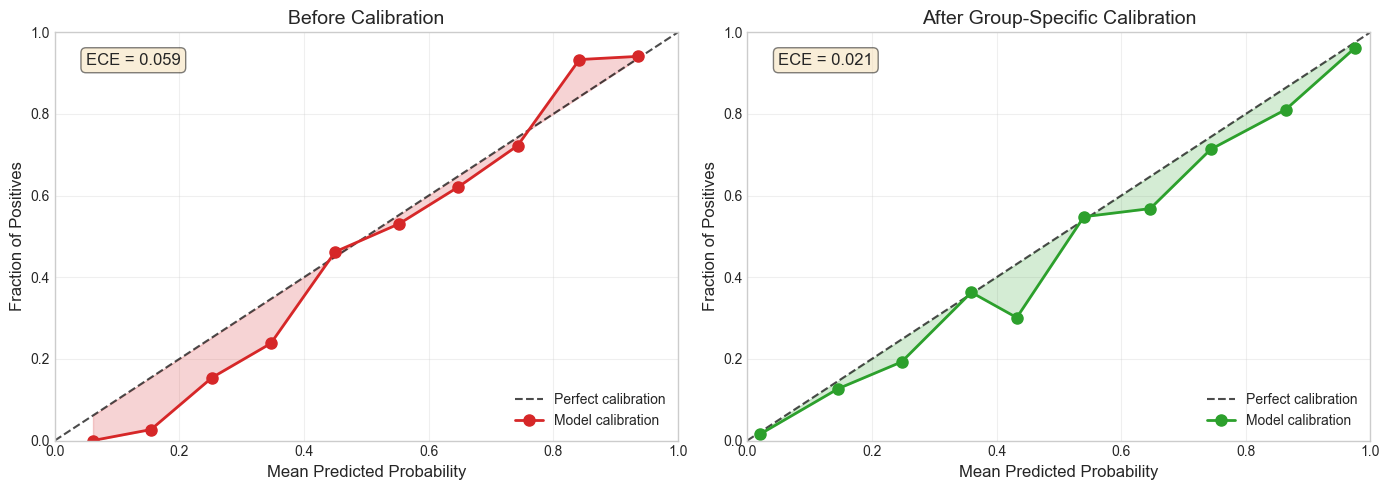

In [19]:
from vfairness.post_processing.calibration.visualization import (
    plot_reliability_diagram,
    plot_group_calibration,
    plot_calibration_disparity,
    plot_calibration_comparison,
    create_calibration_dashboard
)

# Reliability diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_reliability_diagram(
    y_true_recid, y_prob_recid, n_bins=10,
    title="Before Calibration",
    ax=axes[0], show_histogram=False, color='#d62728'
)

plot_reliability_diagram(
    y_true_recid, calibrated_recid, n_bins=10,
    title="After Group-Specific Calibration",
    ax=axes[1], show_histogram=False, color='#2ca02c'
)

plt.tight_layout()
plt.show()

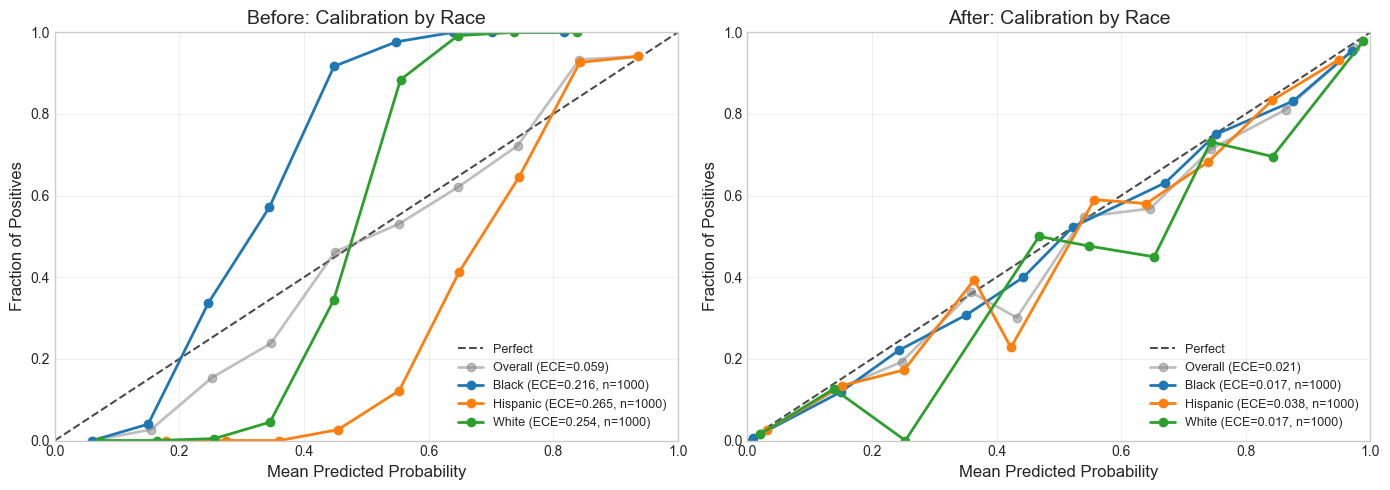

In [20]:
# Group-specific calibration comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_group_calibration(
    y_true_recid, y_prob_recid, race, n_bins=10,
    title="Before: Calibration by Race",
    ax=axes[0]
)

plot_group_calibration(
    y_true_recid, calibrated_recid, race, n_bins=10,
    title="After: Calibration by Race",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

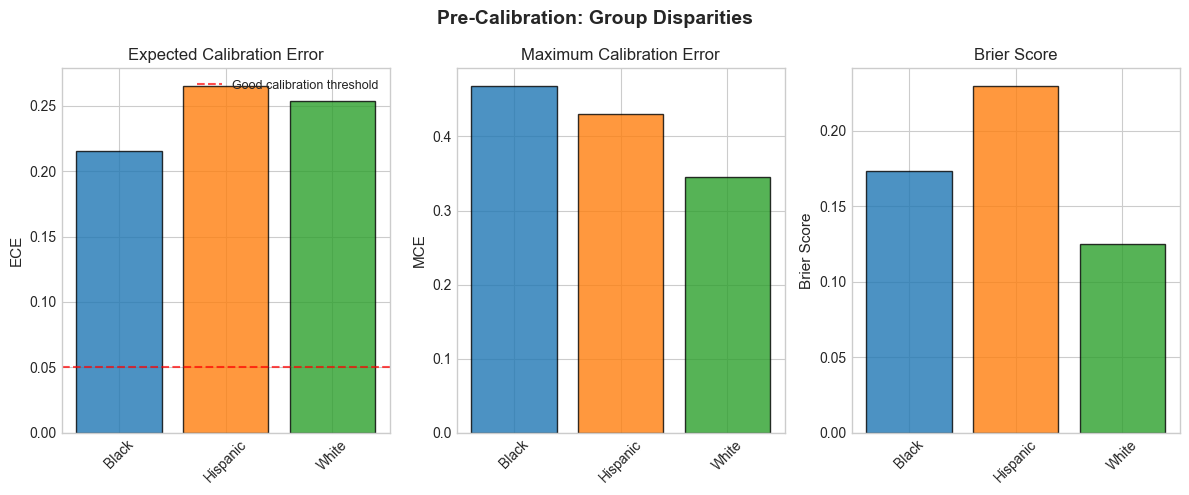

In [21]:
# Calibration disparity visualization
fig = plot_calibration_disparity(
    disparity_recid,
    title="Pre-Calibration: Group Disparities"
)
plt.show()

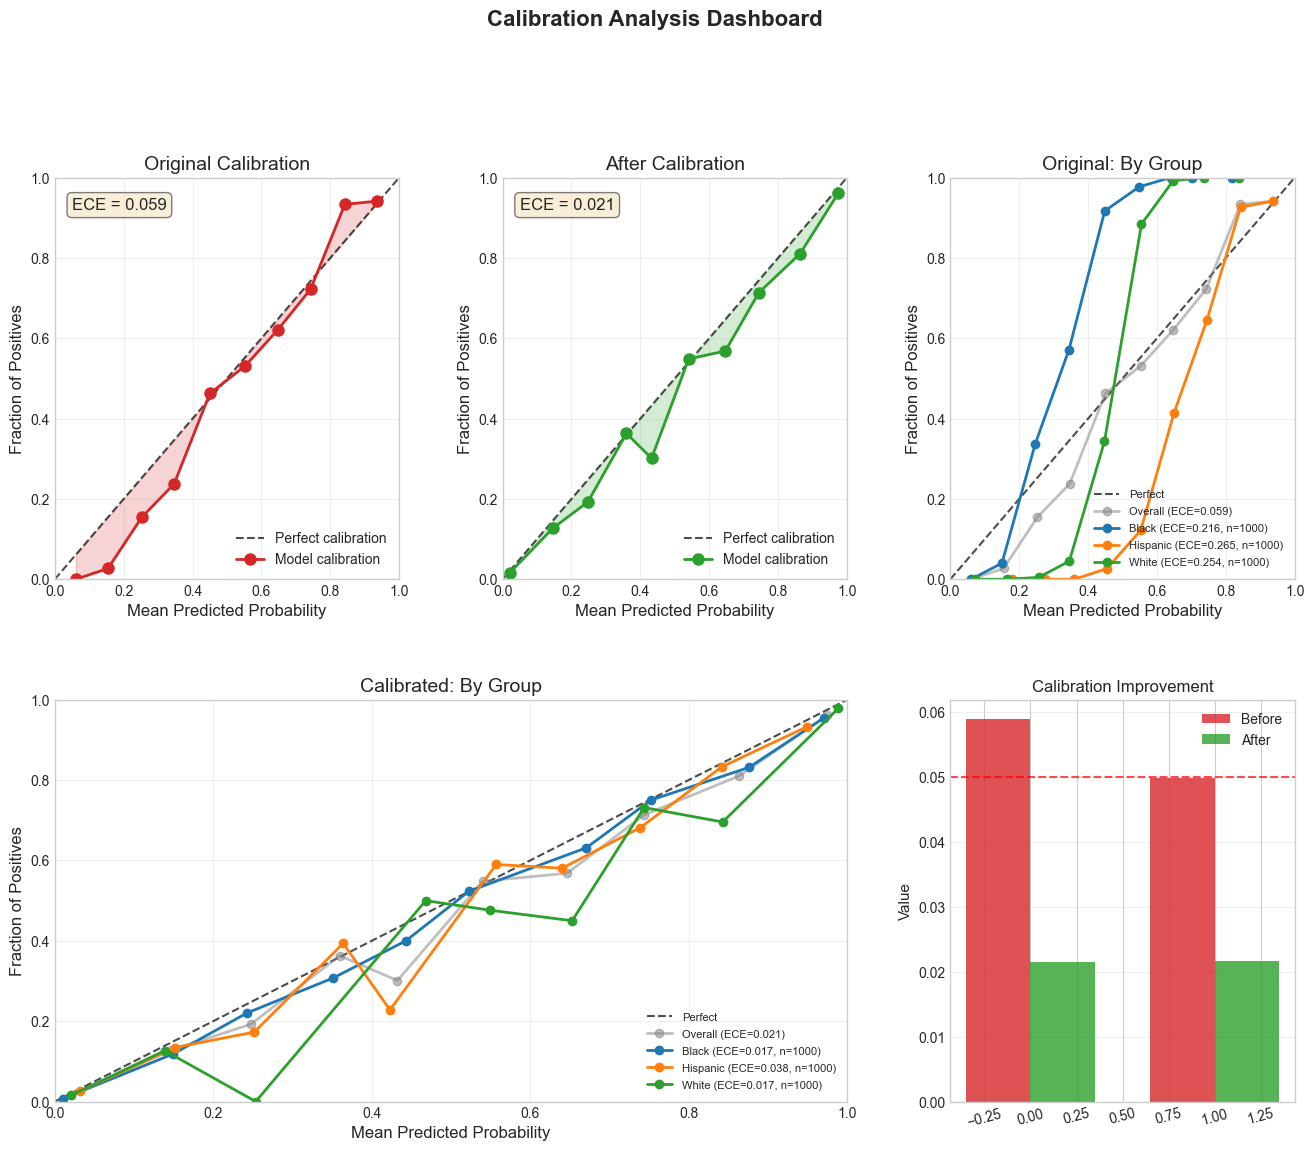

In [22]:
# Comprehensive dashboard
fig = create_calibration_dashboard(
    y_true_recid, y_prob_recid, race,
    calibrated_probs=calibrated_recid,
    n_bins=10,
    figsize=(16, 12)
)
plt.show()

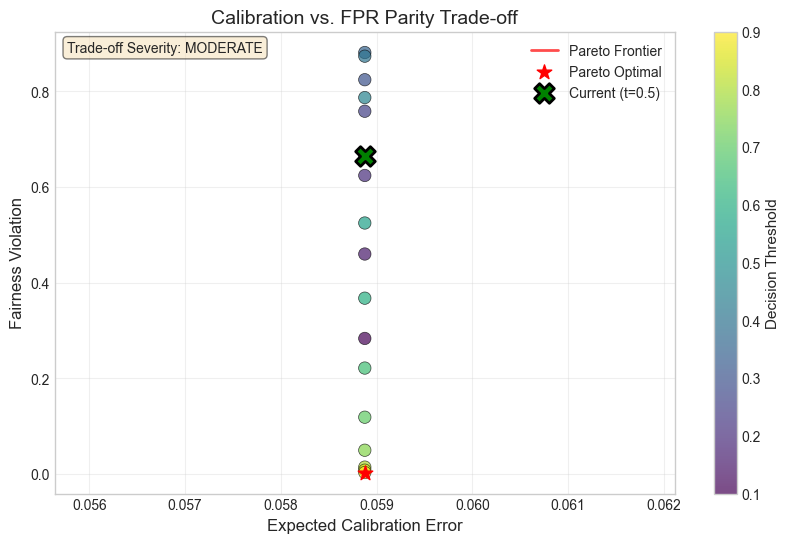

In [23]:
# Trade-off curve visualization
from vfairness.post_processing.calibration.visualization import plot_tradeoff_curve

tradeoff_recid = analyze_calibration_fairness_tradeoff(
    y_true_recid, y_prob_recid, race,
    fairness_metric='fpr_parity',
    thresholds=np.linspace(0.1, 0.9, 17).tolist()
)

ax = plot_tradeoff_curve(
    tradeoff_recid,
    title="Calibration vs. FPR Parity Trade-off"
)
plt.show()

### Classical Pareto Frontier Visualization

The `plot_pareto_frontier` function provides a classical Pareto frontier visualization that:
- Plots only the set of non-dominated points (Pareto optimal)
- Highlights the frontier with a thick colored line
- Optionally shades the dominated region
- Shows clear axis labels for calibration error and fairness violation

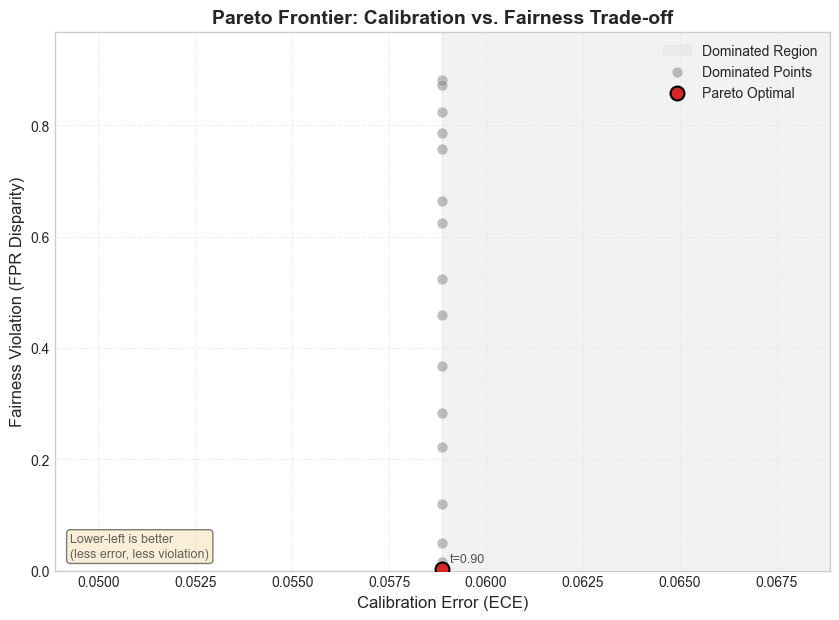


Interpretation:
- Red points on the frontier represent Pareto optimal trade-offs
- Gray shaded area shows dominated region (suboptimal choices)
- Moving along the frontier improves one metric at the cost of the other
- Lower-left corner is ideal but often unattainable


In [24]:
# Classical Pareto Frontier visualization
from vfairness.post_processing.calibration.visualization import plot_pareto_frontier

# Extract calibration errors and fairness violations from trade-off analysis
calibration_errors = [metrics['ece'] for metrics in tradeoff_recid.metrics_at_thresholds.values()]
fairness_violations = [metrics['fairness_violation'] for metrics in tradeoff_recid.metrics_at_thresholds.values()]
threshold_labels = [f't={t:.2f}' for t in tradeoff_recid.metrics_at_thresholds.keys()]

# Plot the classical Pareto frontier
ax = plot_pareto_frontier(
    calibration_errors=calibration_errors,
    fairness_violations=fairness_violations,
    labels=threshold_labels,
    x_label="Calibration Error (ECE)",
    y_label="Fairness Violation (FPR Disparity)",
    title="Pareto Frontier: Calibration vs. Fairness Trade-off",
    highlight_frontier=True,
    shade_dominated=True,
    show_annotations=True,
    figsize=(10, 7)
)
plt.show()

print("\nInterpretation:")
print("- Red points on the frontier represent Pareto optimal trade-offs")
print("- Gray shaded area shows dominated region (suboptimal choices)")
print("- Moving along the frontier improves one metric at the cost of the other")
print("- Lower-left corner is ideal but often unattainable")

<a id='calibration-analyzer'></a>
## 8. CalibrationAnalyzer - Unified Interface

The `CalibrationAnalyzer` class provides a comprehensive, unified interface for all calibration capabilities. It combines calibration evaluation, group-specific calibration, trade-off analysis, and visualization into a single workflow, similar to `BiasDetector` for bias detection and `FairnessAnalyzer` for fairness metrics.

In [25]:
from vfairness.post_processing.calibration import CalibrationAnalyzer, CalibrationReport

# Create analyzer with recidivism data
analyzer = CalibrationAnalyzer(
    y_true=y_true_recid,
    y_prob=y_prob_recid,
    protected_attr=race,
    attribute_name='race',
    n_bins=10,
    min_group_size=50
)

print("CalibrationAnalyzer Created")
print("=" * 50)
print(f"Samples: {analyzer.n_samples}")
print(f"Groups: {analyzer.n_groups} - {analyzer.groups}")
print(f"Overall base rate: {analyzer.base_rate:.3f}")
print(f"\nGroup base rates:")
for group, rate in analyzer.group_base_rates.items():
    print(f"  {group}: {rate:.3f}")

CalibrationAnalyzer Created
Samples: 3000
Groups: 3 - ['Black', 'Hispanic', 'White']
Overall base rate: 0.392

Group base rates:
  Black: 0.439
  Hispanic: 0.377
  White: 0.360


### 8.1 Individual Metric Evaluation

The analyzer provides convenient methods for computing individual metrics:

In [26]:
# Individual metric evaluation
print("Individual Metric Evaluation")
print("=" * 50)

# ECE
ece = analyzer.evaluate_ece()
print(f"\nExpected Calibration Error (ECE):")
print(f"  Overall: {ece.overall_value:.4f}")
print(f"  Well calibrated: {ece.is_well_calibrated}")
print(f"  Max disparity: {ece.max_group_disparity:.4f}")
for group, val in ece.group_values.items():
    print(f"  {group}: {val:.4f}")

# MCE
mce = analyzer.evaluate_mce()
print(f"\nMaximum Calibration Error (MCE):")
print(f"  Overall: {mce.overall_value:.4f}")
for group, val in mce.group_values.items():
    print(f"  {group}: {val:.4f}")

# Brier
brier = analyzer.evaluate_brier()
print(f"\nBrier Score:")
print(f"  Overall: {brier.overall_value:.4f}")
for group, val in brier.group_values.items():
    print(f"  {group}: {val:.4f}")

Individual Metric Evaluation

Expected Calibration Error (ECE):
  Overall: 0.0589
  Well calibrated: False
  Max disparity: 0.0498
  Black: 0.2156
  Hispanic: 0.2654
  White: 0.2541

Maximum Calibration Error (MCE):
  Overall: 0.1275
  Black: 0.4685
  Hispanic: 0.4307
  White: 0.3450

Brier Score:
  Overall: 0.1762
  Black: 0.1737
  Hispanic: 0.2299
  White: 0.1252


In [27]:
# Brier decomposition
decomp = analyzer.decompose_brier()
print("Brier Score Decomposition")
print("=" * 50)
print(f"Brier Score: {decomp.brier_score:.4f}")
print(f"  Reliability: {decomp.reliability:.4f} (lower is better - calibration)")
print(f"  Resolution:  {decomp.resolution:.4f} (higher is better - discrimination)")
print(f"  Uncertainty: {decomp.uncertainty:.4f} (inherent variability)")
print(f"  Skill Score: {decomp.skill_score:.4f}")

Brier Score Decomposition
Brier Score: 0.1762
  Reliability: 0.0054 (lower is better - calibration)
  Resolution:  0.0662 (higher is better - discrimination)
  Uncertainty: 0.2383 (inherent variability)
  Skill Score: 0.2605


### 8.2 Disparity Analysis

Analyze calibration disparities across demographic groups:

In [28]:
# Disparity analysis
disparity = analyzer.analyze_disparity()

print("Calibration Disparity Analysis")
print("=" * 50)
print(f"\nDisparity Metrics:")
print(f"  ECE Disparity: {disparity.ece_disparity:.4f}")
print(f"  MCE Disparity: {disparity.mce_disparity:.4f}")
print(f"  Brier Disparity: {disparity.brier_disparity:.4f}")

print(f"\nGroup Rankings:")
print(f"  Most miscalibrated: {disparity.most_miscalibrated_group}")
print(f"  Least miscalibrated: {disparity.least_miscalibrated_group}")

print(f"\nSignificant disparity (ECE > 0.05): {disparity.has_significant_disparity}")

print(f"\nRecommendations:")
for i, rec in enumerate(disparity.recommendations, 1):
    print(f"  {i}. {rec}")

Calibration Disparity Analysis

Disparity Metrics:
  ECE Disparity: 0.0498
  MCE Disparity: 0.1235
  Brier Disparity: 0.1047

Group Rankings:
  Most miscalibrated: Hispanic
  Least miscalibrated: Black

Significant disparity (ECE > 0.05): False

Recommendations:
  1. LOW: Calibration disparity is acceptable (0.050).
  2. Group 'Hispanic' has poor calibration (ECE=0.265). Consider isotonic regression calibration.


### 8.3 Trade-off Analysis

Analyze calibration-fairness trade-offs and impossibility theorem conditions:

In [29]:
# Trade-off analysis
tradeoffs = analyzer.analyze_tradeoffs(fairness_metric='fpr_parity')

print("Calibration-Fairness Trade-off Analysis")
print("=" * 50)
print(f"\nTrade-off Severity: {tradeoffs.tradeoff_severity.upper()}")
print(f"Base Rate Disparity: {tradeoffs.base_rate_disparity:.3f}")

print(f"\nCurrent Model Position (threshold=0.5):")
print(f"  Calibration Error (ECE): {tradeoffs.current_point.calibration_error:.4f}")
print(f"  Fairness Violation (FPR disparity): {tradeoffs.current_point.fairness_violation:.4f}")
print(f"  Threshold: {tradeoffs.current_point.threshold:.2f}")

print(f"\nPareto Frontier Points: {len(tradeoffs.pareto_points)}")

print(f"\nRecommendations:")
for i, rec in enumerate(tradeoffs.recommendations[:3], 1):
    print(f"  {i}. {rec}")

Calibration-Fairness Trade-off Analysis

Trade-off Severity: MODERATE
Base Rate Disparity: 0.079

Current Model Position (threshold=0.5):
  Calibration Error (ECE): 0.0589
  Fairness Violation (FPR disparity): 0.6642
  Threshold: 0.50

Pareto Frontier Points: 1

Recommendations:
  1. MODERATE TRADE-OFF: Base rate disparity is 7.9%. Some compromise between calibration and fairness may be needed.
  2. MODERATE: ECE of 0.059 suggests room for calibration improvement.
  3. FAIRNESS CONCERN: fpr_parity disparity is 0.664. Consider threshold adjustment or retraining.


In [30]:
# Impossibility theorem diagnostics
impos_diag = analyzer.get_impossibility_diagnosis()

print("Impossibility Theorem Diagnostics")
print("=" * 50)
print(f"\nBase Rates:")
for group, rate in impos_diag['base_rates'].items():
    print(f"  {group}: {rate:.3f}")

print(f"\nBase Rate Disparity: {impos_diag['base_rate_disparity']:.3f}")
print(f"Base Rates Differ: {impos_diag['base_rates_differ']}")
print(f"Impossibility Theorem Applies: {impos_diag['impossibility_applies']}")
print(f"\nExplanation: {impos_diag['explanation']}")

Impossibility Theorem Diagnostics

Base Rates:
  Black: 0.439
  Hispanic: 0.377
  White: 0.360

Base Rate Disparity: 0.079
Base Rates Differ: True
Impossibility Theorem Applies: True

Explanation: Base rates differ slightly (7.9%). Some trade-off exists but may be minor in practice.


### 8.4 Context-Aware Recommendations

Get calibration strategy recommendations tailored to your application domain:

In [ ]:
# Context-aware recommendations for different domains
print("Context-Aware Strategy Recommendations")
print("=" * 60)

contexts = ['risk_assessment', 'lending', 'healthcare', 'hiring', 'general']

for context in contexts:
    # No cache poking needed: the recommendation cache is keyed BY CONTEXT, so
    # each context gets its own entry. (Setting `analyzer._recommendation = None`
    # used to clear a single cached value; it is a dict now, and assigning None
    # makes the next lookup raise TypeError.)
    rec = analyzer.get_recommendation(context=context)
    
    print(f"\n{context.upper().replace('_', ' ')}")
    print("-" * 40)
    print(f"  Strategy: {rec.strategy}")
    print(f"  Priority: {rec.priority}")
    print(f"  Rationale: {rec.rationale[:100]}..." if len(rec.rationale) > 100 else f"  Rationale: {rec.rationale}")
    if rec.expected_improvement:
        print(f"  Expected ECE Improvement: {rec.expected_improvement:.4f}")
    if rec.tradeoff_warning:
        print(f"  ⚠️ Warning: {rec.tradeoff_warning}")

### 8.5 Full Analysis Report

The `full_analysis()` method runs all analyses and produces a comprehensive `CalibrationReport`:

In [32]:
# Clear cached results and run full analysis
analyzer.clear_cache()

# Run full analysis with risk_assessment context
report = analyzer.full_analysis(
    include_tradeoffs=True,
    include_recommendation=True,
    include_brier_decomposition=True,
    context='risk_assessment'
)

# Print the summary
print(report.summary())

CALIBRATION ANALYSIS REPORT
Timestamp: 2026-02-11T15:42:54.872816
Samples: 3000
Groups: 3 (race)

----------------------------------------------------------------------
OVERALL CALIBRATION QUALITY
----------------------------------------------------------------------
Expected Calibration Error (ECE): 0.0589
Maximum Calibration Error (MCE): 0.1275
Brier Score: 0.1762
Well Calibrated: No

----------------------------------------------------------------------
GROUP-SPECIFIC CALIBRATION (ECE)
----------------------------------------------------------------------
  Black: 0.2156
  Hispanic: 0.2654
  White: 0.2541

----------------------------------------------------------------------
CALIBRATION DISPARITY
----------------------------------------------------------------------
ECE Disparity: 0.0498
Significant Disparity: No
Most Miscalibrated: Hispanic
Least Miscalibrated: Black

----------------------------------------------------------------------
BRIER SCORE DECOMPOSITION
-----------------

In [33]:
# Access report attributes programmatically
print("CalibrationReport Attributes")
print("=" * 50)

print(f"\nTimestamp: {report.timestamp}")
print(f"Protected Attribute: {report.protected_attribute}")
print(f"Number of Groups: {report.n_groups}")

print(f"\nOverall Metrics:")
for metric, value in report.overall_metrics.items():
    print(f"  {metric.upper()}: {value:.4f}")

print(f"\nKey Findings:")
print(f"  Well Calibrated: {report.is_well_calibrated}")
print(f"  Significant Disparity: {report.has_significant_disparity}")

print(f"\nCritical Issues ({len(report.critical_issues)}):")
for issue in report.critical_issues[:3]:
    print(f"  [{issue['type']}] {issue['description'][:80]}...")

print(f"\nTop Recommendations:")
for i, rec in enumerate(report.recommendations[:3], 1):
    print(f"  {i}. {rec[:80]}..." if len(rec) > 80 else f"  {i}. {rec}")

CalibrationReport Attributes

Timestamp: 2026-02-11T15:42:54.872816
Protected Attribute: race
Number of Groups: 3

Overall Metrics:
  ECE: 0.0589
  MCE: 0.1275
  BRIER: 0.1762

Key Findings:
  Well Calibrated: False
  Significant Disparity: False

Critical Issues (1):
  [Impossibility Theorem] Base rates differ (7.9%). Perfect calibration and error rate parity cannot both ...

Top Recommendations:
  1. STRATEGY: global_platt_scaling (Priority: medium)
  2. LOW: Calibration disparity is acceptable (0.050).
  3. Group 'Hispanic' has poor calibration (ECE=0.265). Consider isotonic regression ...


### 📊 SVG Visual Dashboard

Generate an SVG calibration dashboard from the report using the `vfairness.rendering` module:

In [ ]:
# Generate SVG dashboard from the calibration report
from IPython.display import SVG, display
from vfairness.rendering import calibration_report_to_svg

svg_output = calibration_report_to_svg(report)
print(f"SVG dashboard size: {len(svg_output):,} bytes")
display(SVG(data=svg_output))

In [34]:
# Export report to JSON for documentation/compliance
import json

report_dict = report.to_dict()
print("Report as JSON (first 1000 chars):")
print("-" * 50)
print(report.to_json()[:1000] + "...")

Report as JSON (first 1000 chars):
--------------------------------------------------
{
  "timestamp": "2026-02-11T15:42:54.872816",
  "data_info": {
    "n_samples": 3000,
    "n_positive": 1176,
    "base_rate": 0.392,
    "n_bins": 10
  },
  "protected_attribute": "race",
  "n_groups": 3,
  "overall_metrics": {
    "ece": 0.05887720635576406,
    "mce": 0.12752894498693956,
    "brier": 0.17624871146806298
  },
  "group_metrics": {
    "Black": {
      "ece": 0.21559517978922624,
      "mce": 0.4684770600581643,
      "brier": 0.17369656030726974
    },
    "Hispanic": {
      "ece": 0.26542901688584525,
      "mce": 0.43074098643384817,
      "brier": 0.2298621175443719
    },
    "White": {
      "ece": 0.25409362739066077,
      "mce": 0.34497548905386677,
      "brier": 0.1251874565525473
    }
  },
  "disparity_analysis": {
    "ece_disparity": 0.04983383709661901,
    "mce_disparity": 0.12350157100429754,
    "brier_disparity": 0.10467466099182463,
    "group_ece": {
      "Bl

### 8.6 Fitting and Applying Calibration

The analyzer can fit a group-specific calibrator and apply it to new data:

In [35]:
# Fit a group-specific calibrator
calibrator = analyzer.fit_calibrator(
    method='isotonic',
    fallback_strategy='global'
)

print("Group-Specific Calibrator Fitted")
print("=" * 50)
print(f"Method: {calibrator.method}")
print(f"Min group size: {calibrator.min_group_size}")
print(f"Groups fitted: {list(calibrator.calibrators_.keys())}")

# Apply calibration to the same data (for demonstration)
calibrated_probs = analyzer.calibrate()

print(f"\nCalibrated probabilities:")
print(f"  Original range: [{y_prob_recid.min():.3f}, {y_prob_recid.max():.3f}]")
print(f"  Calibrated range: [{calibrated_probs.min():.3f}, {calibrated_probs.max():.3f}]")

Group-Specific Calibrator Fitted
Method: isotonic
Min group size: 50
Groups fitted: ['Black', 'Hispanic', 'White']

Calibrated probabilities:
  Original range: [0.050, 0.950]
  Calibrated range: [0.000, 1.000]


In [36]:
# Evaluate improvement after calibration
improvement = analyzer.evaluate_calibration_improvement(calibrated_probs)

print("Calibration Improvement Assessment")
print("=" * 50)

print("\nBEFORE Calibration:")
print(f"  Overall ECE: {improvement['before']['overall_ece']:.4f}")
print(f"  ECE Disparity: {improvement['before']['ece_disparity']:.4f}")
print("  Group ECE:", {k: f"{v:.4f}" for k, v in improvement['before']['group_ece'].items()})

print("\nAFTER Calibration:")
print(f"  Overall ECE: {improvement['after']['overall_ece']:.4f}")
print(f"  ECE Disparity: {improvement['after']['ece_disparity']:.4f}")
print("  Group ECE:", {k: f"{v:.4f}" for k, v in improvement['after']['group_ece'].items()})

print("\nIMPROVEMENT:")
print(f"  Overall ECE: {improvement['improvement']['overall_ece']:+.4f}")
print(f"  ECE Disparity: {improvement['improvement']['ece_disparity']:+.4f}")

Calibration Improvement Assessment

BEFORE Calibration:
  Overall ECE: 0.0589
  ECE Disparity: 0.0498
  Group ECE: {'Black': '0.2156', 'Hispanic': '0.2654', 'White': '0.2541'}

AFTER Calibration:
  Overall ECE: 0.0214
  ECE Disparity: 0.0216
  Group ECE: {'Black': '0.0168', 'Hispanic': '0.0384', 'White': '0.0171'}

IMPROVEMENT:
  Overall ECE: +0.0375
  ECE Disparity: +0.0282


### 8.7 Transform New Data

Apply the fitted calibrator to new/test data using `transform()`:

In [37]:
# Simulate new data (different from training)
np.random.seed(123)
n_new = 500
new_probs = np.random.beta(2, 3, n_new)  # Simulated predictions
new_groups = np.random.choice(['White', 'Black', 'Hispanic'], n_new)

# Transform new data
try:
    calibrated_new = analyzer.transform(new_probs, new_groups)
    
    print("Transforming New Data")
    print("=" * 50)
    print(f"New samples: {n_new}")
    print(f"\nProbability distribution by group (before vs after):")
    
    for group in ['White', 'Black', 'Hispanic']:
        mask = new_groups == group
        orig_mean = new_probs[mask].mean()
        cal_mean = calibrated_new[mask].mean()
        print(f"  {group}: {orig_mean:.3f} → {cal_mean:.3f}")
        
except RuntimeError as e:
    print(f"Error: {e}")
    print("This happens if fit_calibrator() wasn't called first.")

Transforming New Data
New samples: 500

Probability distribution by group (before vs after):
  White: 0.402 → 0.397
  Black: 0.394 → 0.627
  Hispanic: 0.395 → 0.132


### 8.8 Visualizing Calibration Before and After

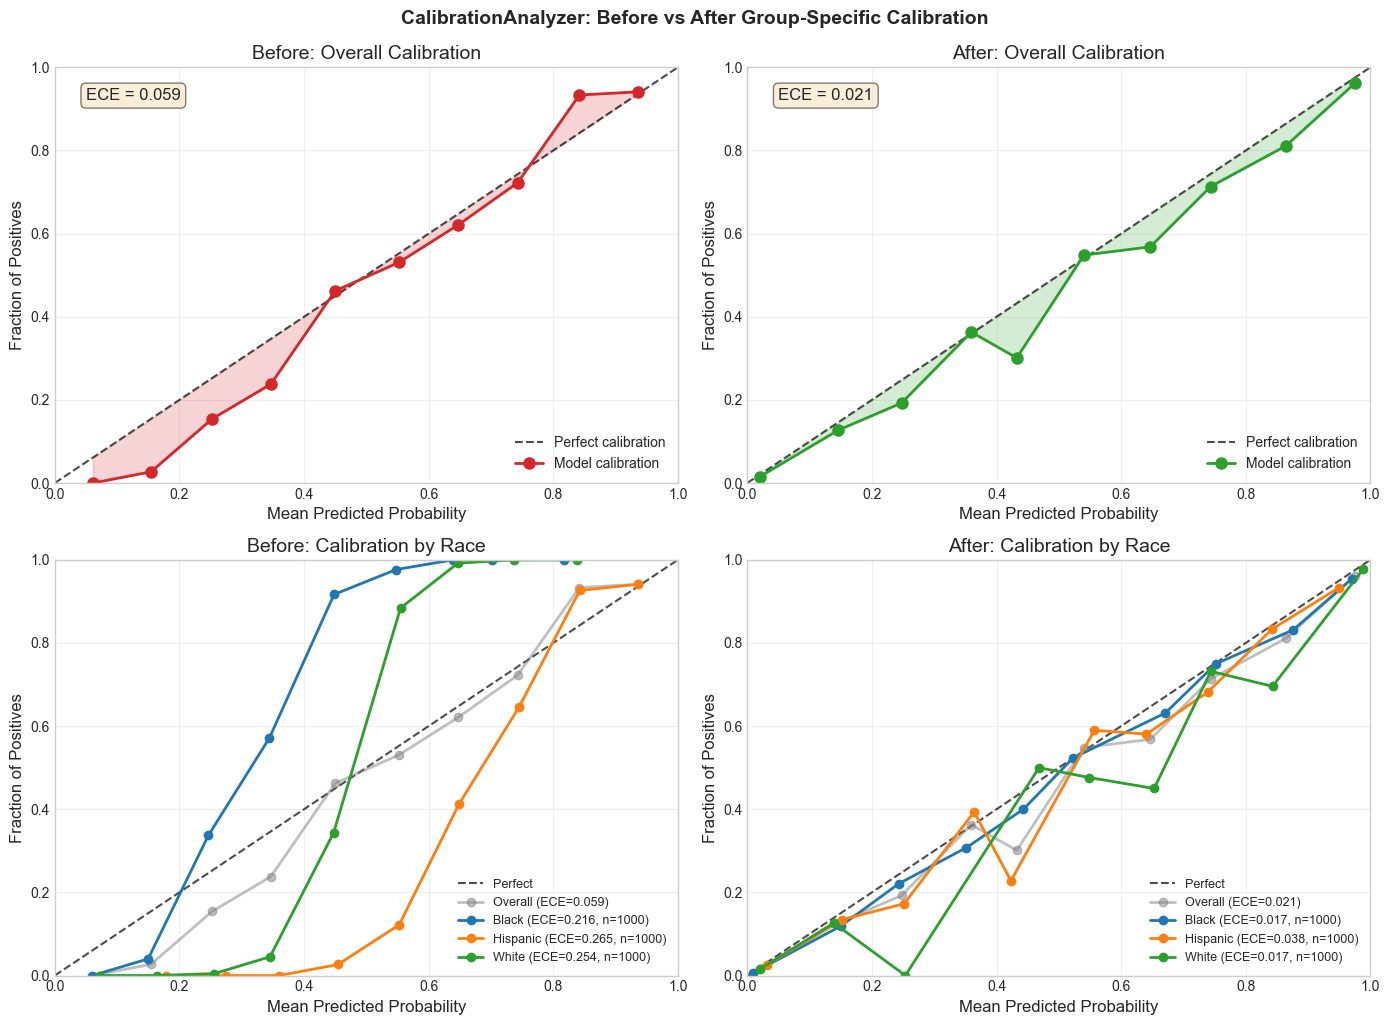

In [38]:
# Visualize the improvement
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Before: Overall reliability diagram
plot_reliability_diagram(
    y_true_recid, y_prob_recid, n_bins=10,
    title="Before: Overall Calibration",
    ax=axes[0, 0], show_histogram=True, color='#d62728'
)

# After: Overall reliability diagram
plot_reliability_diagram(
    y_true_recid, calibrated_probs, n_bins=10,
    title="After: Overall Calibration",
    ax=axes[0, 1], show_histogram=True, color='#2ca02c'
)

# Before: Group-specific
plot_group_calibration(
    y_true_recid, y_prob_recid, race, n_bins=10,
    title="Before: Calibration by Race",
    ax=axes[1, 0]
)

# After: Group-specific
plot_group_calibration(
    y_true_recid, calibrated_probs, race, n_bins=10,
    title="After: Calibration by Race",
    ax=axes[1, 1]
)

plt.tight_layout()
plt.suptitle("CalibrationAnalyzer: Before vs After Group-Specific Calibration", 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 8.9 Data Summary

The analyzer provides a convenient method to get summary statistics:

In [39]:
# Get data summary
summary = analyzer.get_data_summary()

print("Data Summary")
print("=" * 50)
print(f"\nSample Counts:")
print(f"  Total: {summary['n_samples']}")
print(f"  Positive: {summary['n_positive']}")
print(f"  Negative: {summary['n_negative']}")
print(f"  Base Rate: {summary['base_rate']:.3f}")

print(f"\nGroup Information:")
print(f"  Number of groups: {summary['n_groups']}")
print(f"  Groups: {summary['groups']}")
print(f"  Group sizes: {summary['group_sizes']}")
print(f"  Group base rates: {summary['group_base_rates']}")

print(f"\nProbability Statistics:")
print(f"  Min: {summary['prob_stats']['min']:.3f}")
print(f"  Max: {summary['prob_stats']['max']:.3f}")
print(f"  Mean: {summary['prob_stats']['mean']:.3f}")
print(f"  Std: {summary['prob_stats']['std']:.3f}")

Data Summary

Sample Counts:
  Total: 3000
  Positive: 1176
  Negative: 1824
  Base Rate: 0.392

Group Information:
  Number of groups: 3
  Groups: ['Black', 'Hispanic', 'White']
  Group sizes: {'Black': 1000, 'Hispanic': 1000, 'White': 1000}
  Group base rates: {'Black': 0.439, 'Hispanic': 0.377, 'White': 0.36}

Probability Statistics:
  Min: 0.050
  Max: 0.950
  Mean: 0.441
  Std: 0.216


### 8.10 CalibrationAnalyzer Summary

The `CalibrationAnalyzer` class provides a unified interface for all calibration capabilities:

| Method | Purpose |
|--------|---------|
| `evaluate_ece()`, `evaluate_mce()`, `evaluate_brier()` | Individual calibration metrics |
| `decompose_brier()` | Brier score decomposition |
| `evaluate_calibration()` | All metrics at once |
| `analyze_disparity()` | Calibration disparity analysis |
| `analyze_tradeoffs()` | Pareto frontier and trade-off analysis |
| `get_impossibility_diagnosis()` | Kleinberg theorem diagnostics |
| `get_recommendation(context)` | Context-aware strategy recommendation |
| `full_analysis()` | Comprehensive report with all analyses |
| `fit_calibrator(method)` | Fit group-specific calibrator |
| `calibrate()`, `transform()` | Apply calibration |
| `evaluate_calibration_improvement()` | Before/after comparison |
| `get_data_summary()` | Dataset statistics |

**Key Benefits:**
- Single entry point for all calibration functionality
- Caching of results for efficiency
- Context-aware recommendations for different domains
- Export-ready reports (JSON, text summary)
- Integration with visualization tools

### 📊 SVG Visualization Plot Templates

The `vfairness.rendering` module provides SVG plot templates for calibration visualizations.
These render directly from arrays and result dicts — no Matplotlib needed.

In [ ]:
# SVG Reliability Diagram — calibration curve with histogram
import sys
for key in list(sys.modules.keys()):
    if key.startswith('vfairness.rendering'):
        del sys.modules[key]

from vfairness.rendering import (
    reliability_diagram_to_svg, group_calibration_to_svg,
    calibration_disparity_to_svg, pareto_frontier_to_svg,
)
from IPython.display import SVG, display

svg = reliability_diagram_to_svg(y_true, y_prob, n_bins=10)
print(f'Reliability Diagram SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Group Calibration — per-group calibration curves
svg = group_calibration_to_svg(y_true, y_prob, protected_attr, n_bins=10)
print(f'Group Calibration SVG: {len(svg):,} bytes')
display(SVG(data=svg))

In [ ]:
# SVG Calibration Disparity: ECE comparison across groups
#
# `CalibrationDisparityResult` carries per-group ECE in `group_ece` (a plain
# {group: float} mapping) and the spread in `ece_disparity`. The adapter wants a
# dict shaped as {'group_metrics': {group: {'ece': ...}}, 'ece_disparity': ...},
# so this cell is the bridge between the two. Older versions of this notebook
# looked for `disparity.group_metrics` and `max_ece_disparity`, neither of which
# is a field on the result.
disp_dict = {
    'group_metrics': {g: {'ece': float(e)} for g, e in disparity.group_ece.items()},
    'ece_disparity': float(disparity.ece_disparity),
    'most_miscalibrated_group': disparity.most_miscalibrated_group,
}
svg = calibration_disparity_to_svg(disp_dict)
print(f'Calibration Disparity SVG: {len(svg):,} bytes')
display(SVG(data=svg))


In [ ]:
# SVG Pareto Frontier — accuracy vs fairness trade-off
svg = pareto_frontier_to_svg(
    calibration_errors=calibration_errors,
    fairness_violations=fairness_violations,
    labels=[f'Model {i+1}' for i in range(len(calibration_errors))],
)
print(f'Pareto Frontier SVG: {len(svg):,} bytes')
display(SVG(data=svg))

---
## FairnessExplainer — Educational Explanations

The `FairnessExplainer` facade provides educational, context-aware explanations for any result object in the vfairness library. Each major class also exposes a convenience `get_explanation()` method.

In [ ]:
# FairnessExplainer — unified explanation facade
from vfairness.explainer import FairnessExplainer

# Option 1: Convenience method on the class
explanation = analyzer.get_explanation(report)
print(explanation)
print()

# Option 2: Via the unified facade
explanation2 = FairnessExplainer.explain(report)
print(f"Title   : {explanation2.title}")
print(f"Severity: {explanation2.severity}")
print(f"Summary : {explanation2.summary}")
print()
for expl in explanation2.explanations:
    print(f"  [{expl.severity.upper():8s}] {expl.metric_name}: {expl.value}")

In [ ]:
# ── Validation · FairnessExplainer ───────────────────────────────────────────
from vfairness.explainer import FairnessExplainer, ExplanationReport

explanation = analyzer.get_explanation(report)

assert isinstance(explanation, ExplanationReport), \
    f"Expected ExplanationReport, got {type(explanation).__name__}"
assert explanation.title == 'Calibration Analysis Explanation', \
    f"Unexpected title: {explanation.title}"
assert len(explanation.explanations) > 0, \
    "ExplanationReport should contain at least one explanation"
assert explanation.severity in ('info', 'low', 'medium', 'high', 'critical'), \
    f"Invalid severity: {explanation.severity}"
assert FairnessExplainer.can_explain(report) is True

print(f"✓ FairnessExplainer | {len(explanation.explanations)} explanation(s) | "
      f"severity={explanation.severity} | facade ✓")

## Summary

The vfairness calibration module provides:

1. **Calibration Metrics**: ECE, MCE, Brier score decomposition, and calibration curves for quantifying calibration quality

2. **Calibration Methods**: Multiple techniques (Platt, Isotonic, Beta, Temperature, Histogram) for transforming probabilities

3. **Group-Specific Calibration**: Tools for ensuring consistent probability interpretation across demographic groups

4. **Trade-off Analysis**: Understanding the fundamental tension between calibration and other fairness criteria (impossibility theorem)

5. **Context-Aware Recommendations**: Application-specific guidance for calibration strategy

6. **Visualization**: Comprehensive plotting tools for reliability diagrams, group comparisons, and trade-off frontiers

7. **CalibrationAnalyzer**: A unified interface combining all capabilities with caching, reporting, and context-aware recommendations

### Key Takeaways

- **Calibration is a distinct fairness dimension** - models can be accurate but miscalibrated across groups
- **Group-specific calibration** can significantly reduce interpretation disparities
- **Trade-offs are unavoidable** when base rates differ - the impossibility theorem applies
- **Context matters** - different applications have different calibration vs. fairness priorities
- **CalibrationAnalyzer** provides a one-stop solution for comprehensive calibration analysis

### References

- Pleiss, G., et al. (2017). On Fairness and Calibration. NeurIPS.
- Kleinberg, J., et al. (2016). Inherent Trade-offs in Fair Risk Scores.
- Naeini, M. P., et al. (2015). Obtaining Well Calibrated Probabilities. AAAI.
- Guo, C., et al. (2017). On Calibration of Modern Neural Networks. ICML.